In [1]:
# 1: Load Lena Image and Convert to Grayscale

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Convert to RGB (OpenCV loads as BGR by default)
lena = cv2.imread('lena.png')
lena_rgb = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)

# Convert to grayscale
lena_gray = cv2.cvtColor(lena, cv2.COLOR_BGR2GRAY)

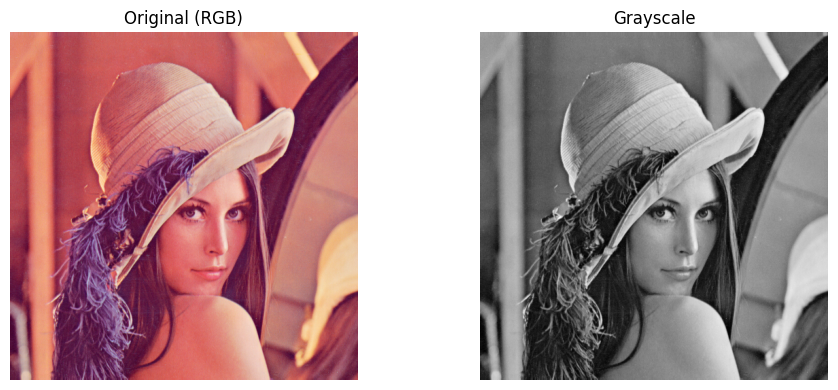

In [3]:
# Plot original and grayscale
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original (RGB)")
plt.imshow(lena_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Grayscale")
plt.imshow(lena_gray, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# 2: Gamma Encoding Function
def gamma_encode(image: np.ndarray, gamma: float) -> np.ndarray:
    """
    Gamma encodes the grayscale image using 1/gamma.
    Args:
        image: Input grayscale image as numpy array (uint8, range 0–255)
        gamma: Gamma value for encoding
    Returns:
        Encoded image (float32, range 0–1)
    """
    # Normalize image to [0, 1]
    image_norm = image / 255.0
    # Apply gamma encoding (1/gamma)
    encoded = np.power(image_norm, 1.0 / gamma)
    return encoded

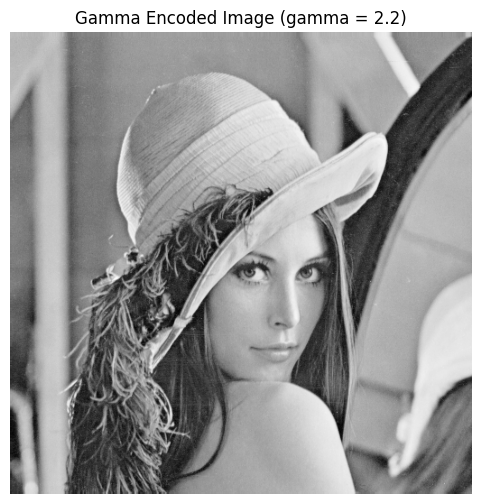

In [5]:
# 3: Encode Lena grayscale image using gamma = 2.2
gamma_value = 2.2

encoded_img = gamma_encode(lena_gray, gamma_value)

# Display encoded image (scaled back to 0-255 for visualization)
plt.figure(figsize=(6,6))
plt.title(f"Gamma Encoded Image (gamma = {gamma_value})")
plt.imshow(encoded_img, cmap='gray')
plt.axis('off')
plt.show()

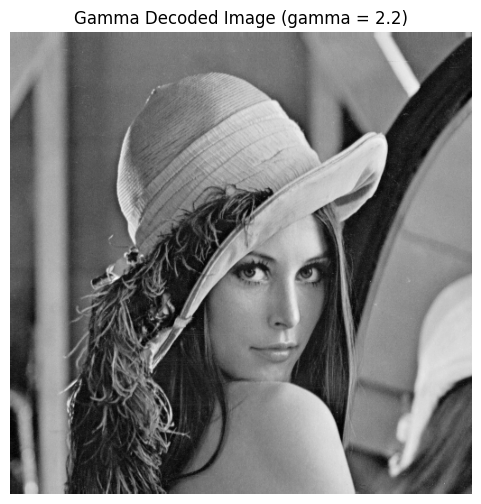

In [ ]:
# 📌 4: Decode the gamma-encoded image using gamma = 2.2
def gamma_decode(image, gamma):
    return np.power(image, gamma)

decoded_img = gamma_decode(encoded_img, gamma_value)

# Display decoded image
plt.figure(figsize=(6,6))
plt.title(f"Gamma Decoded Image (gamma = {gamma_value})")
plt.imshow(decoded_img, cmap='gray')
plt.axis('off')
plt.show()

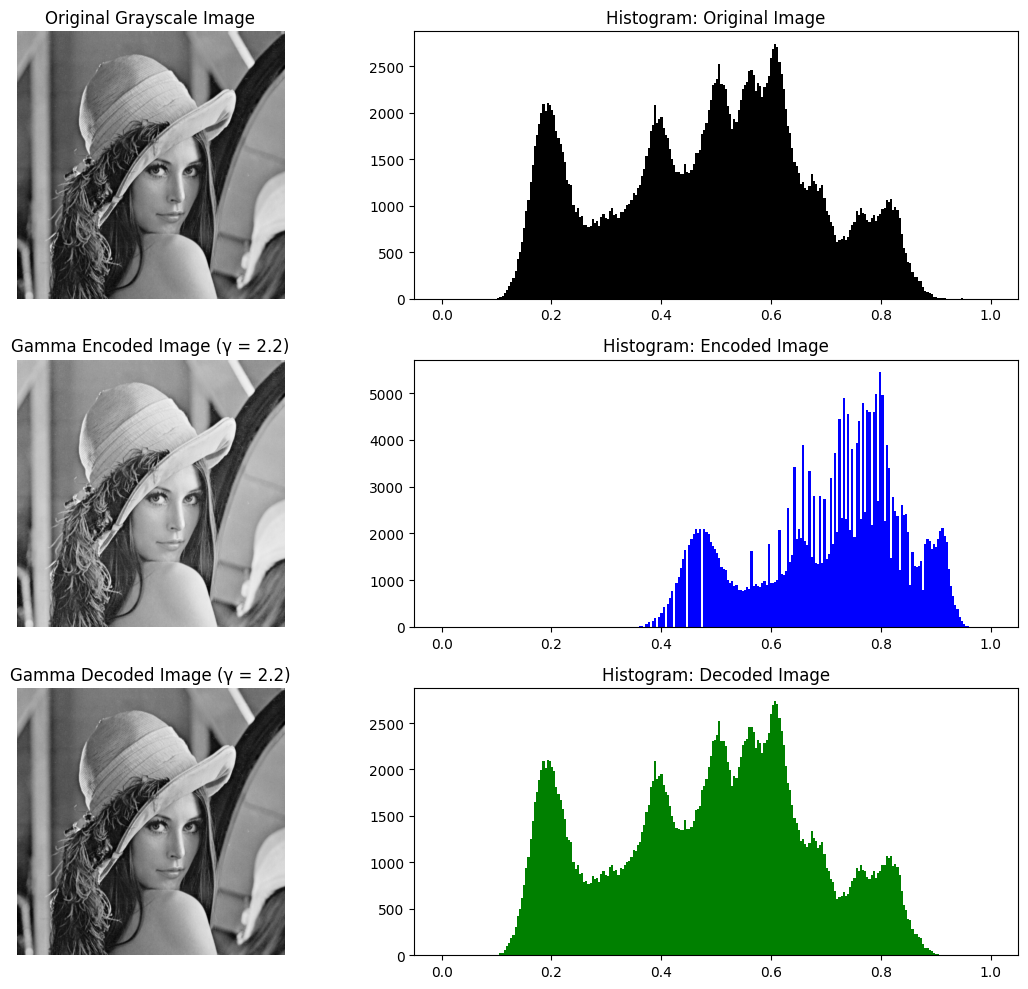

In [8]:
# 5: Plot original, encoded, and decoded images with histograms
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Original Image
axes[0, 0].imshow(lena_gray, cmap='gray')
axes[0, 0].set_title("Original Grayscale Image")
axes[0, 0].axis('off')

axes[0, 1].hist((lena_gray / 255).ravel(), bins=256, range=(0, 1), color='black')
axes[0, 1].set_title("Histogram: Original Image")

# Encoded Image
axes[1, 0].imshow(encoded_img, cmap='gray')
axes[1, 0].set_title("Gamma Encoded Image (γ = 2.2)")
axes[1, 0].axis('off')

axes[1, 1].hist(encoded_img.ravel(), bins=256, range=(0, 1), color='blue')
axes[1, 1].set_title("Histogram: Encoded Image")

# Decoded Image
axes[2, 0].imshow(decoded_img, cmap='gray')
axes[2, 0].set_title("Gamma Decoded Image (γ = 2.2)")
axes[2, 0].axis('off')

axes[2, 1].hist(decoded_img.ravel(), bins=256, range=(0, 1), color='green')
axes[2, 1].set_title("Histogram: Decoded Image")

plt.tight_layout()
plt.show()

In [ ]:
encoding_gamma = 2.2
encoded_img = gamma_encode(lena_gray, encoding_gamma)

decoding_gammas = [1.0, 1.8, 2.2, 4.0]
decoded_images = []

for gamma in decoding_gammas:
    decoded = gamma_decode(encoded_img, gamma)
    decoded_images.append(decoded)

TypeError: 'float' object is not callable

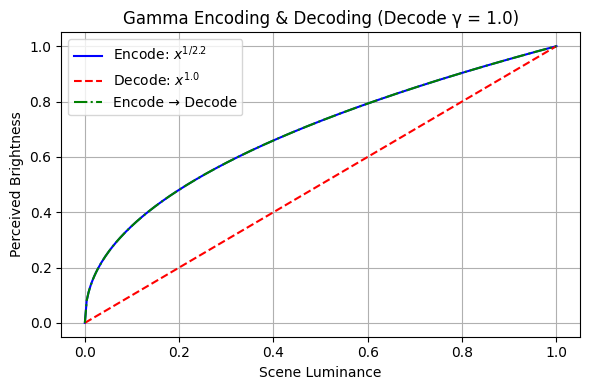

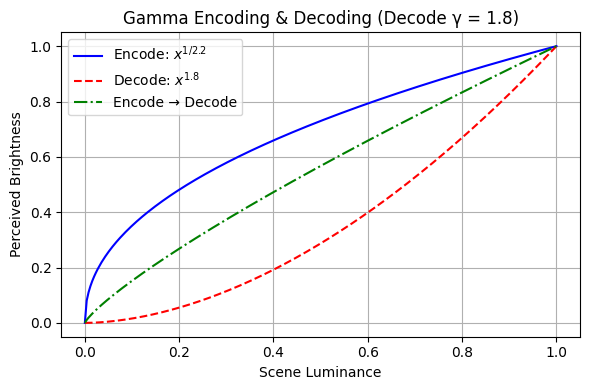

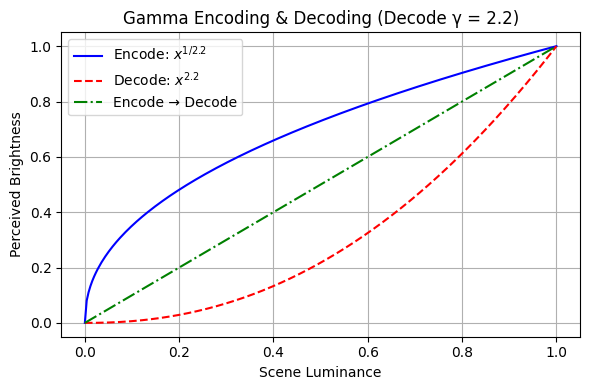

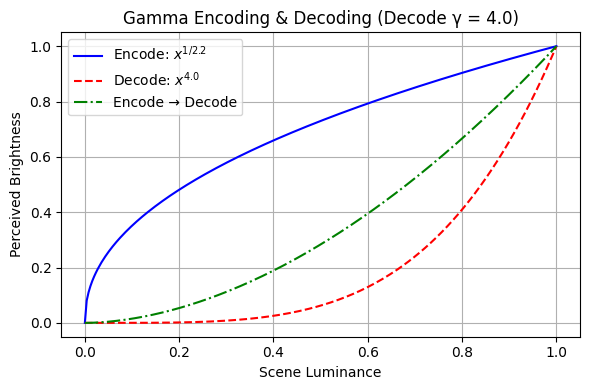

In [9]:
# Scene luminance range
x = np.linspace(0, 1, 256)

# Fixed encoding gamma (as per instruction)
gamma_encode = 2.2

# Try different decoding gammas
decode_gammas = [1.0, 1.8, 2.2, 4.0]

for gamma_decode in decode_gammas:
    plt.figure(figsize=(6, 4))

    # Blue: Encoding function y = x^(1/gamma)
    encoded = np.power(x, 1/gamma_encode)
    plt.plot(x, encoded, color='blue', label=f'Encode: $x^{{1/{gamma_encode}}}$')

    # Red: Decode function directly on original image: y = x^gamma_decode
    decoded_direct = np.power(x, gamma_decode)
    plt.plot(x, decoded_direct, color='red', linestyle='--', label=f'Decode: $x^{{{gamma_decode}}}$')

    # Green: Decode after encoding
    round_trip = np.power(encoded, gamma_decode)
    plt.plot(x, round_trip, color='green', linestyle='-.', label='Encode → Decode')

    plt.title(f'Gamma Encoding & Decoding (Decode γ = {gamma_decode})')
    plt.xlabel('Scene Luminance')
    plt.ylabel('Perceived Brightness')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()